In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglikebasic
import modeselector
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 0.25     # Total time

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")
# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
## NOTE: BELOW THIS ALL ARE FIXED
xI0 = 1.0
dist = 0.5 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# NOTE: change verbose argument for debugging
loglike_obj = loglikebasic.LogLike(params_star, waveform_gen_comb, gwf, M_init=5, verbose=False, waveform_gen_sep=waveform_gen_sep, noise_weighted=True)
print('Done initializing loglike class.')
print("Setting up log_density and prior functions...")
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")

Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Setting up log_density and prior functions...
Calculating SNR...
SNR calculated: 107.43944631400305
Setting up log_density and prior functions...


In [85]:

def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = loglike

    return log_likes

# NOTE: OLDIEEE
def prior_transform(u):

    # # sampling_test => 30x fisher box
    # logm1lim = [5.995531126784557, 6.004468873215443]
    # logm2lim = [1.4746191268598186, 1.4796233825795062]
    # alim = [0.6919479173260448, 0.7080520826739551]
    # p0lim = [7.455582230927566, 7.544417769072434]
    # e0lim = [0.3980771809772245, 0.40192281902277555]

    # box1 = 3 x box of sampling_test= 90x fisher box
    logm1lim = [5.9865933803536695, 6.0134066196463305]
    logm2lim = [1.469614871140131, 1.4846276382991939]
    alim = [0.6758437519781343, 0.7241562480218656]
    p0lim = [7.366746692782698, 7.633253307217302]
    e0lim = [0.3942315429316735, 0.40576845706832654]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    
    return transformed

In [ ]:
ndim=5

In [4]:
n_samples = int(1e5)
xlimits = np.column_stack([
        np.zeros(ndim, dtype=float),
        np.ones(ndim, dtype=float),
    ])
sampling = LHS(xlimits=xlimits)
lhs_points = np.clip(sampling(n_samples), 0.0, 1.0)

In [5]:
physical_points = prior_transform(lhs_points)

# Load from pkl

In [3]:
with open('lhs_logden.pkl', 'rb') as f:
    physical_points, logden = pickle.load(f)

In [6]:
physical_points.shape

(100000, 5)

In [7]:
len(logden)

100000

In [8]:
np.max(logden)

0.01246314982317979

In [9]:
np.min(logden)

-7.29984862556366e-05

In [13]:
param_max = physical_points[np.argmax(logden)]
param_max

array([5.99987492, 1.48368776, 0.70266178, 7.51924844, 0.39662759])

change prior from box1 -> sampling_test here pls

In [20]:
ffunc_sampler = parismc.Sampler.load_state('./sampling_test/paris_intrinsic_ffunc_extlhs/sampler_state.pkl')

In [21]:
ffunc_samples, ffunc_weights = ffunc_sampler.get_samples_with_weights(flatten=True)

In [22]:
param_ranges = [(5.9865933803536695, 6.0134066196463305), (1.469614871140131, 1.4846276382991939),
    (0.6758437519781343, 0.7241562480218656), (7.366746692782698, 7.633253307217302), 
                (0.3942315429316735, 0.40576845706832654)]

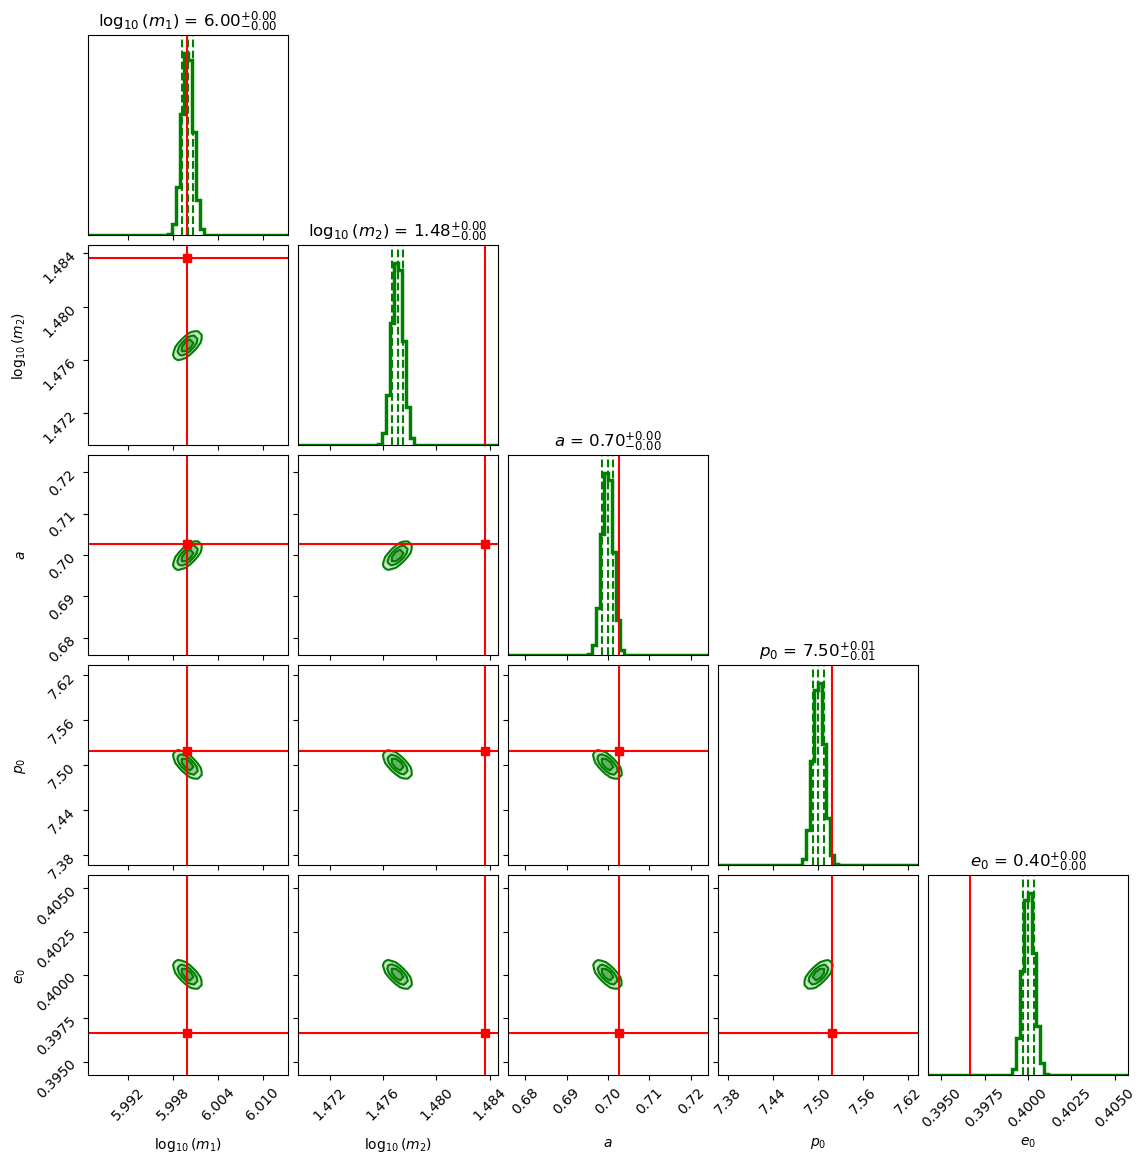

In [23]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    ffunc_samples,
    weights=ffunc_weights,
    labels=labels,
    truths=param_max,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=50,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

In [31]:
physical_points[np.argmax(logden)]

array([5.99987492, 1.48368776, 0.70266178, 7.51924844, 0.39662759])

In [32]:
param_true

[6.0, 1.4771212547196624, 0.7, 7.5, 0.4]

In [35]:
log_density(np.array([param_true]))

array([82.47292943])

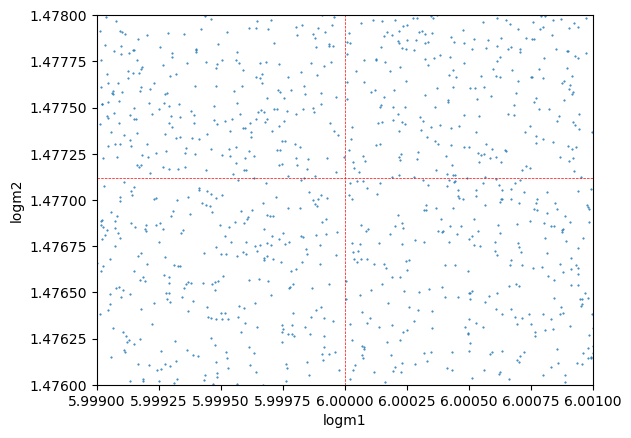

In [58]:

plt.plot(physical_points[:, 0], physical_points[:, 1], "o", markersize=0.5)
plt.axhline(y=param_true[1], color='r', linestyle='--', linewidth=0.5)
plt.axvline(x=param_true[0], color='r', linestyle='--', linewidth=0.5)
plt.xlabel("logm1")
plt.ylabel("logm2")
plt.xlim(5.999, 6.001)
plt.ylim(1.476, 1.478)
plt.show()

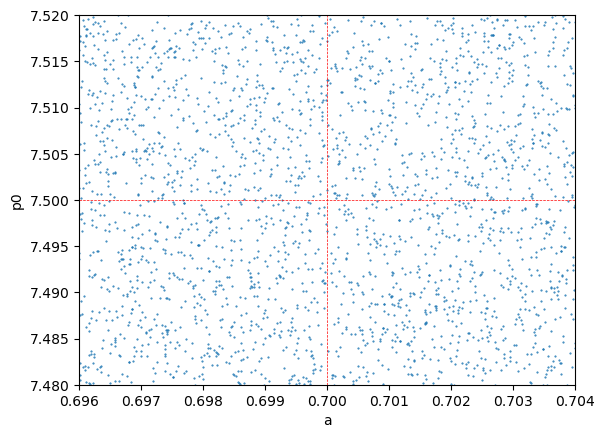

In [59]:

plt.plot(physical_points[:, 2], physical_points[:, 3], "o", markersize=0.5)
plt.axhline(y=param_true[3], color='r', linestyle='--', linewidth=0.5)
plt.axvline(x=param_true[2], color='r', linestyle='--', linewidth=0.5)
plt.xlabel("a")
plt.ylabel("p0")
plt.xlim(0.696,0.704)
plt.ylim(7.48,7.52)
plt.show()

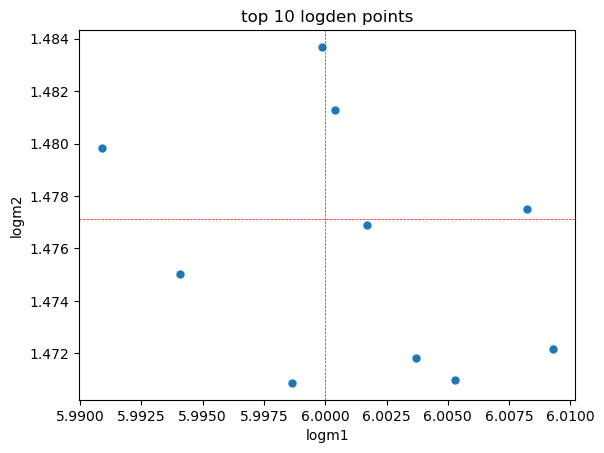

In [67]:
# plot top logden points
top_logden_indices = np.argsort(logden)[-10:]
top_physical_points = physical_points[top_logden_indices]
top_logden_values = logden[top_logden_indices]
plt.plot(top_physical_points[:, 0], top_physical_points[:, 1], "o", markersize=5)
plt.axhline(y=param_true[1], color='r', linestyle='--', linewidth=0.5)
plt.axvline(x=param_true[0], color='r', linestyle='--', linewidth=0.5)
plt.xlabel("logm1")
plt.ylabel("logm2")
plt.title('top 10 logden points')
plt.show()

In [73]:
physical_points[:,0].min(), physical_points[:,0].max()

(5.986593514419866, 6.013406485580134)

In [72]:
top_physical_points[:,0].min(), top_physical_points[:,0].max()

(5.990880415117976, 6.0092737610079565)

In [78]:
def inverse_prior_transform(x):
    # sampling_test => 30x fisher box
    # logm1lim = [5.995531126784557, 6.004468873215443]
    # logm2lim = [1.4746191268598186, 1.4796233825795062]
    # alim = [0.6919479173260448, 0.7080520826739551]
    # p0lim = [7.455582230927566, 7.544417769072434]
    # e0lim = [0.3980771809772245, 0.40192281902277555]

    # box1 = 3 x box of sampling_test= 90x fisher box
    logm1lim = [5.9865933803536695, 6.0134066196463305]
    logm2lim = [1.469614871140131, 1.4846276382991939]
    alim = [0.6758437519781343, 0.7241562480218656]
    p0lim = [7.366746692782698, 7.633253307217302]
    e0lim = [0.3942315429316735, 0.40576845706832654]

    u = np.zeros_like(x)
    
    # Inverse of: transformed = (max - min) * u + min
    # Solution: u = (transformed - min) / (max - min)
    
    u[:, 0] = (x[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (x[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (x[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (x[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (x[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    
    return u

In [79]:
top_points = inverse_prior_transform(top_physical_points)

In [80]:
xlimits_refined = np.array([
    [top_points[:, 0].min(), top_points[:, 0].max()],
    [top_points[:, 1].min(), top_points[:, 1].max()],
    [top_points[:, 2].min(), top_points[:, 2].max()],
    [top_points[:, 3].min(), top_points[:, 3].max()],
    [top_points[:, 4].min(), top_points[:, 4].max()],
])

In [81]:
xlimits_refined

array([[0.159885, 0.845865],
       [0.083335, 0.937395],
       [0.084895, 0.862225],
       [0.104475, 0.973775],
       [0.080095, 0.581435]])

In [84]:
sampling_refined = LHS(xlimits=xlimits_refined)
lhs_refined = sampling_refined(int(1e4))

change back to 3x box for prior_transform here pls

In [86]:
physical_points_refined = prior_transform(lhs_refined)

In [ ]:
logden_refined = log_density(physical_points_refined)

In [89]:
logden_refined

array([ 3.39991938e-05, -3.27046263e-06,  5.66935486e-08, ...,
        3.97411269e-07, -1.12491169e-05, -1.94147868e-07])